In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

def train_random_forest(csv_path="data/asos_seoul_daily_enriched.csv",
                        model_path="models/randomforest_enriched_model.pkl",
                        fig_path="outputs/randomforest_eval_plots.png"):
    # 1. 데이터 불러오기
    df = pd.read_csv(csv_path, parse_dates=['tm'])# 모델링용 데이터 읽기(trainer.py참조)

    # 2. 결측치 제거
    df = df.dropna() #xgb에서는 결측치를 미리 중앙값으로 처리함

    # 3. 특성 / 타겟 분리
    X = df.drop(columns=['tm', 'flood_risk']) #독립변수 : tm(시간)과 flood_risk(타겟)을 제외한 나머지 모든 컬럼
    y = df['flood_risk'] #타겟변수 : 침수 위험도(0, 1)

    # 4. 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42 #독립변수:타겟변수=80:20. stratify=y: 침수 위험도의 비율을 훈련/테스트 세트에서 동일하게 유지
    )

    # 5. 모델 학습(정규화 없음)
    model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')#트리:300개, 불균현 데이터를 위한 클래스 가중치 자동 조정(침수 발생일이 적기 때문)
    model.fit(X_train, y_train) #학습

    # 6. 예측 및 평가
    y_pred = model.predict(X_test) #0또는 1예측
    y_proba = model.predict_proba(X_test)[:, 1]  #침수 위험도 확률(0~1사이)

    print("Confusion Matrix:") #Confusion Matrix: 실제 vs 예측의 교차표
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")  #Classification Report: 정밀도, 재현율, F1-score 등
    print(classification_report(y_test, y_pred))
    print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba):.3f}") #ROC AUC Score: 분류 성능 종합 지표

    # 7. 시각화 저장
    # 1행 3열 서브플롯으로 Confusion Matrix, ROC Curve, Precision-Recall Curve를 나란히 배치
    plt.figure(figsize=(15, 4))

    #Confusion Matrix
    plt.subplot(1, 3, 1)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=plt.gca())
    plt.title("Confusion Matrix")

    # ROC Curve
    plt.subplot(1, 3, 2)
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=plt.gca()) #gca() : 현재 축을 가져와서 각 서브플롯에 그래프 그리기
    plt.title("ROC Curve")

    #Precision-Recall Curve
    plt.subplot(1, 3, 3)
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=plt.gca())
    plt.title("Precision-Recall Curve")

    plt.tight_layout()
    plt.savefig(fig_path)
    plt.show()

    # 8. 모델 저장
    joblib.dump(model, model_path)
    print(f"모델 저장 완료: {model_path}")


In [7]:
# 1. 데이터 불러오기
df = pd.read_csv('C:/Project1/CREW_SOOM_final/data/asos_seoul_daily_enriched.csv', parse_dates=['tm']) # 모델링용 데이터 읽기(trainer.py참조)

# 2. 결측치 제거
df = df.dropna() #xgb에서는 결측치를 미리 중앙값으로 처리함

# 3. 특성 / 타겟 분리
X = df.drop(columns=['tm', 'flood_risk']) #독립변수 : tm(시간)과 flood_risk(타겟)을 제외한 나머지 모든 컬럼
y = df['flood_risk'] #타겟변수 : 침수 위험도(0, 1)
# 4. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42 #독립변수:타겟변수=80:20. stratify=y: 침수 위험도의 비율을 훈련/테스트 세트에서 동일하게 유지
)

# 5. 모델 학습(정규화 없음)
model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')#트리:300개, 불균현 데이터를 위한 클래스 가중치 자동 조정(침수 발생일이 적기 때문)
model.fit(X_train, y_train) #학습

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [8]:
y_pred = model.predict(X_test) #0또는 1예측
y_proba = model.predict_proba(X_test)[:, 1]  #침수 위험도 확률(0~1사이)
print(y_pred, y_proba)

[0 1 0 ... 1 0 0] [0.07333333 1.         0.         ... 0.99666667 0.00333333 0.        ]


In [9]:
print("Confusion Matrix:") #Confusion Matrix: 실제 vs 예측의 교차표
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")  #Classification Report: 정밀도, 재현율, F1-score 등
print(classification_report(y_test, y_pred))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba):.3f}") #ROC AUC Score: 분류 성능 종합 지표

Confusion Matrix:
[[1764    1]
 [  21   64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1765
           1       0.98      0.75      0.85        85

    accuracy                           0.99      1850
   macro avg       0.99      0.88      0.92      1850
weighted avg       0.99      0.99      0.99      1850


ROC AUC Score: 0.983


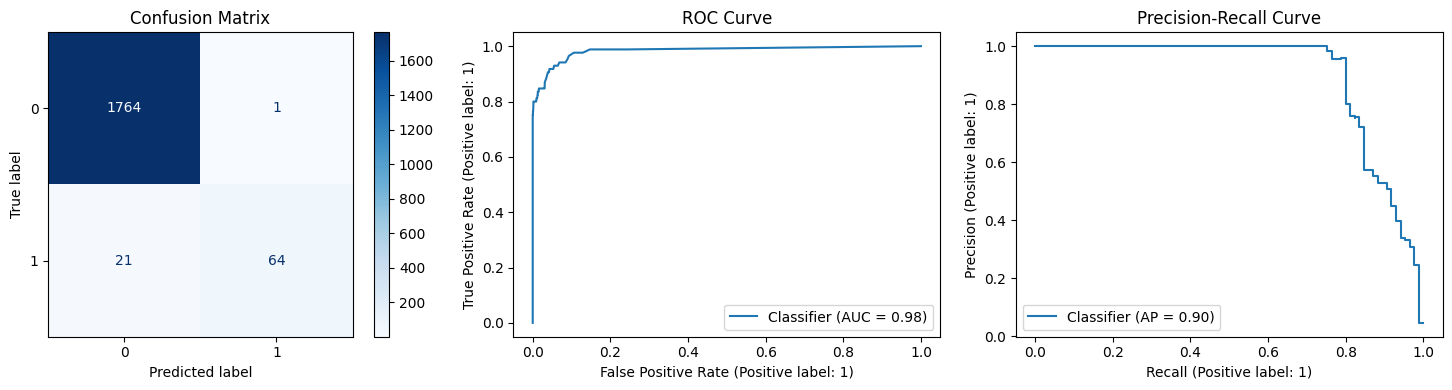

In [12]:
plt.figure(figsize=(15, 4))

#Confusion Matrix
plt.subplot(1, 3, 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix")

# ROC Curve
plt.subplot(1, 3, 2)
RocCurveDisplay.from_predictions(y_test, y_proba, ax=plt.gca()) #gca() : 현재 축을 가져와서 각 서브플롯에 그래프 그리기
plt.title("ROC Curve")

#Precision-Recall Curve
plt.subplot(1, 3, 3)
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=plt.gca())
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()